In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scanpy as sc

from build_graph import *

In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
# low dpi (dots per inch) yields small inline figures
# sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

In [30]:
adata = sc.datasets.paul15()
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [31]:
adata.X

array([[0., 0., 0., ..., 0., 2., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 3., ..., 2., 3., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [3., 0., 3., ..., 0., 1., 0.],
       [0., 0., 4., ..., 1., 1., 1.]], dtype=float32)

In [3]:
DATA_PATH = '../../../oscb/uploads/'

OUTPUT_PATH = '../../../oscb/uploads/outputs/'

adata = sc.read_h5ad('../../../oscb/uploads/outputs/planaria-full.h5ad')
adata

AnnData object with n_obs × n_vars = 18837 × 2000
    obs: 'labels'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'benchmark_traj', 'hvg', 'log1p', 'origin_group'
    layers: 'raw_counts'

In [4]:
adata.X = adata.layers["raw_counts"].copy()

In [27]:
# adata.uns["iroot"]

840

In [5]:
# adata.uns["iroot"]='neoblast 1'

In [23]:
# adata.write_h5ad(DATA_PATH + 'planaria-full.h5ad')

In [5]:
def run_scanpy_trajectory(adata, cell_type_label='labels', origin_group=adata.uns['origin_group'], color=["leiden"], n_neighbors=4, n_pcs=20, resolution=1.0):

    adata.X = adata.X.astype("float64")

    sc.pp.recipe_zheng17(adata)
    sc.tl.pca(adata, svd_solver="arpack")
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.draw_graph(adata)
    # Denoising the graph
    sc.tl.diffmap(adata)
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep="X_diffmap")
    sc.tl.leiden(adata, resolution=resolution)
    sc.tl.paga(adata, groups="leiden")
    sc.pl.paga(adata, color=color)
    # Recomputing the embedding using PAGA-initialization
    sc.tl.draw_graph(adata, init_pos="paga", key_added_ext="trajectory")

    if cell_type_label is not None and cell_type_label in adata.obs.keys() and origin_group is not None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
        build_graph(adata, 
                    use_rep='X_draw_graph_trajectory', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                    k=10,            # K for building a KNN graph.
                    device=device)
        
        build_trajectory(adata, 
                        use_groups=cell_type_label,       # cell labels used to infer trajectory
                        origin_group=origin_group, # set the root cell label of trajectory
                        use_community=None,          # If None, use cell labels to build cell community.
                        traj_shape='mdo_tree',       # Choose build-in tree shape trajectory inference method.
                        device=device) 

    sc.pl.paga_compare(
        adata,
        threshold=0.03,
        title="",
        right_margin=0.2,
        size=10,
        edge_width_scale=0.5,
        legend_fontsize=12,
        fontsize=12,
        frameon=False,
        edges=True,
        save=True,  # save figure to file figures/paga_compare.pdf
    )

    return adata

/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(
adata.X seems to be already log-transformed.
/opt/conda/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/opt/conda/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/opt/conda/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_23641/1067424008.py:12: FutureWarning

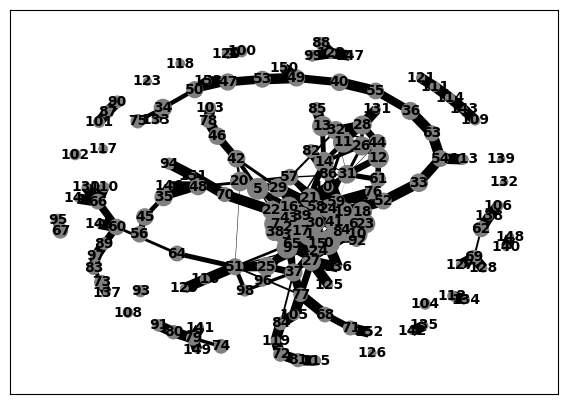

/app/Machine-learning-development-environment-for-single-cell-sequencing-data-analyses/api/test/build_graph.py:290: RuntimeWarning: divide by zero encountered in divide
  attention_matrix = 1/(numpy.log(aaa + 1))
saving figure to file figures/paga_compare.pdf


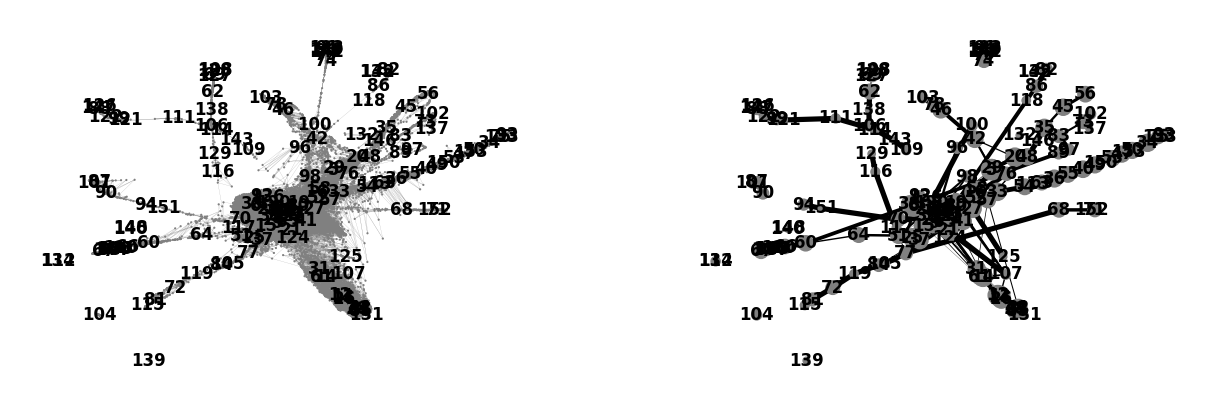

AnnData object with n_obs × n_vars = 18837 × 1000
    obs: 'labels', 'n_counts_all', 'leiden'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'mean', 'std'
    uns: 'benchmark_traj', 'hvg', 'log1p', 'origin_group', 'pca', 'neighbors', 'draw_graph', 'diffmap_evals', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'edge_index', 'community', 'trajectory', 'connectivities'
    obsm: 'X_pca', 'X_draw_graph_fa', 'X_diffmap', 'X_draw_graph_trajectory'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [6]:
adata = run_scanpy_trajectory(adata)
adata

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
build_graph(adata, 
     use_rep='X_draw_graph_trajectory', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
     k=10,            # K for building a KNN graph.
     device=device)

In [9]:
build_trajectory(adata, 
                 use_groups = 'labels',       # cell labels used to infer trajectory
                 origin_group = 'neoblast 1', # set the root cell label of trajectory
                 use_community=None,          # If None, use cell labels to build cell community.
                 traj_shape='mdo_tree',       # Choose build-in tree shape trajectory inference method.
                 device=device)     # save trajectory into CSV file.

/app/Machine-learning-development-environment-for-single-cell-sequencing-data-analyses/api/test/build_graph.py:290: RuntimeWarning: divide by zero encountered in divide
  attention_matrix = 1/(numpy.log(aaa + 1))


In [10]:
adata

AnnData object with n_obs × n_vars = 18837 × 1000
    obs: 'labels', 'n_counts_all', 'leiden'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'mean', 'std'
    uns: 'benchmark_traj', 'hvg', 'log1p', 'origin_group', 'pca', 'neighbors', 'draw_graph', 'diffmap_evals', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'edge_index', 'community', 'trajectory', 'connectivities'
    obsm: 'X_pca', 'X_draw_graph_fa', 'X_diffmap', 'X_draw_graph_trajectory'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [11]:
adata.uns['trajectory']

,from,to,weight
0,neoblast 1,epidermal neoblasts,1.023693
1,neoblast 1,neural progenitors,1.167401
2,neoblast 1,protonephridia,1.293779
3,neoblast 1,gut progenitors,1.351082
4,neoblast 1,parenchymal progenitors,1.376604
5,neoblast 1,secretory 1,1.410915
6,neoblast 1,goblet cells,1.684924
7,neural progenitors,spp-11+ neurons,0.579527
8,protonephridia,pharynx cell type progenitors,0.466807
9,parenchymal progenitors,ldlrr-1+ parenchymal cells,0.436636


In [12]:
adata.uns['benchmark_traj']

,from,to,length,directed
1,neoblast 1,epidermal neoblasts,1,True
2,epidermal neoblasts,early epidermal progenitors,1,True
3,early epidermal progenitors,late epidermal progenitors 1,1,True
4,late epidermal progenitors 1,late epidermal progenitors 2,1,True
5,late epidermal progenitors 2,epidermis,1,True
6,neoblast 1,parenchymal progenitors,1,True
7,parenchymal progenitors,pigment,1,True
8,parenchymal progenitors,aqp+ parenchymal cells,1,True
9,parenchymal progenitors,psap+ parenchymal cells,1,True
10,parenchymal progenitors,ldlrr-1+ parenchymal cells,1,True


In [8]:
def adjacency_matrix_to_edge_list(adj_matrix):
    edge_list = []
    num_nodes = adj_matrix.shape[0]

    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if adj_matrix[i, j] != 0:
                edge_list.append((i, j, adj_matrix[i, j]))
                edge_list.append((j, i, adj_matrix[i, j]))

    return edge_list

In [8]:
# edge_list = adjacency_matrix_to_edge_list(adata.obsp["connectivities"])

In [ ]:
edge_list

In [13]:
import random
import numpy as np
import networkx as nx
import zss
from math import inf
from grakel import GraphKernel, Graph


def trajectory_metrics(traj, bm_traj, root_node):
    # Graph edit distance
    traj_dict = traj_to_dict(traj)
    bm_traj_dict = traj_to_dict(bm_traj)
    traj_ls = []
    for key in traj_dict.keys():
        traj_ls.append((traj_dict[key], key)) 

    bm_traj_ls = []
    for key in bm_traj_dict.keys():
        bm_traj_ls.append((bm_traj_dict[key], key))

    traj_ls = sorted(traj_ls, key=lambda edge: (edge[0], edge[1]))
    bm_traj_ls = sorted(bm_traj_ls, key=lambda edge: (edge[0], edge[1]))
    
    G1 = nx.DiGraph()
    G1.add_edges_from(bm_traj_ls)

    G2 = nx.DiGraph()
    G2.add_edges_from(traj_ls)

    # Calculate the graph edit distance
    distance = graph_edit_distance(G1, G2)
    
    max_distance = 4*len(bm_traj_dict.keys()) + 2
    
    ged_score = (max_distance-distance)/max_distance


    # Jaccard similarity coefficient
    total_n = len(bm_traj_dict.keys()) + len(traj_dict.keys())

    nn = 0
    for key in bm_traj_dict.keys():
        if key in traj_dict.keys():
            if bm_traj_dict[key] == traj_dict[key]:
                nn += 1

    total_n = total_n - nn
    jsc_score = nn/total_n


    # Graph kernel score
    traj_ls = sorted(traj_ls, key=lambda edge: (edge[0], edge[1]))
    bm_traj_ls = sorted(bm_traj_ls, key=lambda edge: (edge[0], edge[1]))

    gks_score = graph_kernel_score(bm_traj_ls, traj_ls, root_node=root_node)


    # Tree edit distance
    # Build trees from edge lists
    bm_tree = build_tree_from_edges(bm_traj_ls, root_node)
    tree = build_tree_from_edges(traj_ls, root_node)

    # Calculate tree edit distance
    tree_distance = zss.distance(
        tree, bm_tree,
        get_children=lambda node: node.children,
        insert_cost=insert_cost,
        remove_cost=remove_cost,
        update_cost=update_cost
    )
    tree_max_distance = 2*len(bm_traj_dict.keys())-2
    ted_score = (tree_max_distance-tree_distance)/tree_max_distance

    mean = (ged_score + gks_score + jsc_score + ted_score)/4

    return float('{:.4f}'.format(ged_score)), float('{:.4f}'.format(gks_score)), float('{:.4f}'.format(jsc_score)), float('{:.4f}'.format(ted_score)), float('{:.4f}'.format(mean))


def traj_to_dict(df):
    graph = {}
    for i, row in df.iterrows():
        graph[row['to']] = row['from']
        
    return graph



class TreeNode:
    def __init__(self, label):
        self.label = label
        self.children = []


def build_tree_from_edges(edges, root_node):
    nodes = {}
    for parent, child in edges:
        if parent not in nodes:
            nodes[parent] = TreeNode(parent)
        if child not in nodes:
            nodes[child] = TreeNode(child)
        nodes[parent].children.append(nodes[child])
    return nodes[root_node]  # Return the root node


def insert_cost(node):
    return 1


def remove_cost(node):
    return 1


def update_cost(node1, node2):
    return 0 if node1.label == node2.label else inf


def graph_edit_distance(G1, G2):
    # Initialize cost for edges
    node_cost = 0
    nodes1 = set(G1.nodes)
    nodes2 = set(G2.nodes)

    # Calculate edge substitution cost
    for node1 in nodes1:
        if node1 in nodes2:
            nodes2.remove(node1)  # Matched edges
        else:
            node_cost += 1  # Unmatched edge in G1 (deletion)

    node_cost += len(nodes2)  # Remaining unmatched edges in G2 (insertion)

    # Initialize cost for edges
    edge_cost = 0
    edges1 = set(G1.edges)
    edges2 = set(G2.edges)

    # Calculate edge substitution cost
    for edge1 in edges1:
        if edge1 in edges2:
            edges2.remove(edge1)  # Matched edges
        else:
            edge_cost += 1  # Unmatched edge in G1 (deletion)

    edge_cost += len(edges2)  # Remaining unmatched edges in G2 (insertion)

    return node_cost + edge_cost


def graph_kernel_score(edges1, edges2, root_node):
    edges1 = find_root_node(edges1, root_node)
    edges2 = find_root_node(edges2, root_node)

    G1 = nx.Graph()
    G1.add_edges_from(edges1)

    G2 = nx.Graph()
    G2.add_edges_from(edges2)
    
    grakel_G1 = nx_to_grakel(G1)
    grakel_G2 = nx_to_grakel(G2)

    # Initialize the Weisfeiler-Lehman subtree kernel
    gk = GraphKernel(kernel={"name": "shortest_path"}, normalize=True)

    # Compute the kernel matrix
    G = [grakel_G1, grakel_G2]
    K = gk.fit_transform(G)
    
    final_score = K[0,1]
    
    return final_score

# Convert NetworkX graphs to Grakel format
def nx_to_grakel(G):
    nodes = list(G.nodes)
    edges = list(G.edges)
    node_labels = {node: i for i, node in enumerate(nodes)}
    edges_transformed = [(node_labels[edge[0]], node_labels[edge[1]]) for edge in edges]
    return (edges_transformed, {i: label for label, i in node_labels.items()})


def find_root_node(edges1, root_node):
    if edges1[0][0] == root_node:
        pass

    else:
        for i in range(1, len(edges1)):
            if edges1[i][0] == root_node:
                aaa = edges1[0]
                edges1[0] = edges1[i]
                edges1[i] = aaa
                i = len(edges1)+1
            else:
                pass
            
    return edges1

In [14]:
ged_score, gks_score, jsc_score, ted_score, mean = trajectory_metrics(adata.uns['trajectory'], adata.uns['benchmark_traj'], 'neoblast 1')

In [19]:
mean

0.4862

In [16]:
gks_score

0.3623

In [15]:
ged_score

0.7692

In [17]:
jsc_score

0.3617

In [18]:
ted_score

0.4516

In [9]:
import torch
import scipy
import numpy
import math
from sklearn.ensemble import IsolationForest
import random
from os import cpu_count
from scipy.spatial import cKDTree


def build_adj_graph(adata, use_rep='X_diffmap', k=10, data_dtype = torch.float32, device='cpu'):
    """
    """
    
    feature_matrix = extract_data_matrix_from_adata(adata, use_rep=use_rep, torch_tensor=True, 
                                                    data_dtype=data_dtype, device=device)
    edge_index = hidden_build_edge_index(feature_matrix, 
                                         k_min=0, 
                                         k_max=k, 
                                         self_edge=True, 
                                         remov_edge_prob=None, 
                                         node_IF_labels=None,
                                         device=device)
    
    adata.uns['adj_edge_index'] = edge_index.cpu().numpy()


def build_graph(adata, use_rep="X_dif", k=10, self_edge = False, prune=False, data_dtype = torch.float32, device='cpu'):
    """
    """
    
    feature_matrix = extract_data_matrix_from_adata(adata, use_rep=use_rep, torch_tensor=True, 
                                                    data_dtype=data_dtype, device=device)
    node_IF_labels = numpy.array(adata.obs['isolation']) if prune else None
    edge_index = hidden_build_edge_index(feature_matrix, 
                                         k_min=0, 
                                         k_max=k, 
                                         self_edge=self_edge, 
                                         remov_edge_prob=None, 
                                         node_IF_labels=node_IF_labels, 
                                         device=device)
    edge_index = edge_index.cpu().numpy()
    
    adata.uns['edge_index'] = edge_index


def extract_data_matrix_from_adata(adata, use_rep=None, torch_tensor=True, data_dtype=torch.float32, device='cpu'):
    """
    """

    if use_rep is not None:
        feature_matrix = adata.obsm[use_rep]
    elif isinstance(adata.X, scipy.sparse.spmatrix): 
        feature_matrix = adata.X.todense()
    else:
        feature_matrix = adata.X
        
    if torch_tensor:
        try:
            feature_matrix = torch.tensor(feature_matrix, dtype=data_dtype, device=device)  
        except ValueError as e:
            # Check if the error is due to negative strides
            if "negative strides" in str(e):
                print("Caught ValueError due to negative strides in the given numpy array. Transform it into contiguous array.")
                feature_matrix= np.ascontiguousarray(feature_matrix)
                feature_matrix = torch.tensor(feature_matrix, dtype=data_dtype, device=device) 
            else:
                raise e
        
    return feature_matrix
    

def hidden_build_edge_index(feature_matrix, k_min=0, k_max=10, self_edge=False, remov_edge_prob=None, node_IF_labels=None, device='cpu'):
    
    num_of_nodes = feature_matrix.size()[0]
    
    edge_index = knn_graph(feature_matrix.to(device), k_min=k_min, k_max=k_max, self_edge=self_edge)
    
    if node_IF_labels is not None:
        edge_index = prune_fn(edge_index, node_IF_labels)
        
    if remov_edge_prob is not None:
        mask = torch.rand(edge_index.size(1)) > remov_edge_prob
        edge_index = edge_index[:, mask]
        
    return edge_index


def knn_graph(feature_matrix, k_min=0, k_max=10, self_edge = False):
    """
    """
   
    # Calculate the pairwise squared distances between points
    dist_matrix = torch.cdist(feature_matrix, feature_matrix, p=2)

    # Find the indices of the k nearest neighbors for each point
    if self_edge:
        knn_indices = torch.argsort(dist_matrix, dim=1)[:, k_min: k_max]  # Exclude the point itself (at index 0)
        # construct edge index from knn_indices
        edge_index = knn_indices_to_edge_index(knn_indices)
    
    else:
        knn_indices = torch.argsort(dist_matrix, dim=1)[:, k_min+1: k_max+1] # the point itself may not at index 0(overlapped points)
        # construct edge index from knn_indices
        edge_index = knn_indices_to_edge_index(knn_indices)

        mask = edge_index[0] != edge_index[1]
        edge_index = edge_index[:, mask]

    return edge_index


def knn_indices_to_edge_index(knn_indices):
    """
    """
    num_points, k = knn_indices.shape

    # Create source and target node index tensors
    src_nodes = torch.arange(num_points, device=knn_indices.device).view(-1, 1).repeat(1, k).view(-1)
    trg_nodes = knn_indices.reshape(-1)

    # Concatenate the source and target node index tensors to create the edge_index tensor
    edge_index = torch.stack([src_nodes, trg_nodes], dim=0)

    return edge_index


def edge_index_to_adj(edge_index, num_of_nodes):
    """
    construct adjacency matrix from edge index
    """
    adjacency_matrix = torch.zeros((num_of_nodes, num_of_nodes), dtype=edge_index.dtype, device=edge_index.device)
    adjacency_matrix[edge_index[0], edge_index[1]] = 1

    return adjacency_matrix



def prune_fn(edge_index, node_IF_labels):
    
    node_IF_labels = torch.tensor(node_IF_labels, device=edge_index.device)
    
    normal_nodes = torch.where(node_IF_labels == 1)[0]
    anomalous_nodes = torch.where(node_IF_labels == -1)[0]
    
    mask_1 = torch.isin(edge_index[0,:], anomalous_nodes)
    mask_2 = torch.isin(edge_index[1,:], normal_nodes)
    
    mask = mask_1 & mask_2

    edge_index = edge_index[:,~mask]
    
    return edge_index

In [10]:
def get_community(adata, use_groups='labels', community_name='community'):
    
    groups = adata.obs[use_groups].astype(str)
    community_size = {}
    community_component = {}
    community_keys = groups.unique()
    
    for group_name in community_keys:
        community_component[group_name] = numpy.where(groups == group_name)[0]
        community_size[group_name] = len(community_component[group_name])/len(groups)
    
    adata.uns[community_name] = {}
    adata.uns[community_name]['use_groups'] = use_groups
    adata.uns[community_name]['keys'] = community_keys
    adata.uns[community_name]['component'] = community_component
    adata.uns[community_name]['size'] = community_size


def community_umap(adata, use_umap='X_umap', use_community='community'):
    
    groups = adata.obs[adata.uns[use_community]['use_groups']].astype(str)
    
    feature_umap = adata.obsm[use_umap]
    
    community_umap = {}
    array_umap = []

    for group_name in adata.uns[use_community]['keys']:
        group_umap = feature_umap[numpy.where(groups == group_name)[0], :]
        community_umap[group_name] = group_umap.mean(axis=0)
        array_umap.append(community_umap[group_name])
    
    adata.uns[use_community]['pos_dict'] = community_umap
    adata.uns[use_community]['pos_array'] = tune_community_umap(numpy.array(array_umap), 
                                                               tune_pos=0.3, 
                                                               tune_pos_scale=1.0)
    for ii in range(len(adata.uns[use_community]['keys'])):
        group_name = adata.uns[use_community]['keys'][ii]
        adata.uns[use_community]['pos_dict'][group_name] = adata.uns[use_community]['pos_array'][ii,:]



def tune_community_umap(community_umap, tune_pos=0.3, tune_pos_scale=1.0):
    
    range_1 = community_umap[:, 0].max() - community_umap[:, 0].min()
    range_2 = community_umap[:, 1].max() - community_umap[:, 1].min()
    
    distances = pdist(community_umap, metric='euclidean')

    # Convert the condensed distance matrix to a square matrix
    distance_matrix = squareform(distances)

    threshold = tune_pos*numpy.mean(distances)

    # Extract node pairs with distance below the mean distance
    node_pairs_below = []

    for i in range(distance_matrix.shape[0]):
        for j in range(i+1, distance_matrix.shape[1]):
            if distance_matrix[i][j] < threshold:
                node_pairs_below.append((i, j))

    for node_pairs in node_pairs_below:

        umap_1 = community_umap[node_pairs[0]]
        umap_2 = community_umap[node_pairs[1]]
        umap_dif = umap_2 - umap_1
        distance = math.sqrt(umap_dif[0]*umap_dif[0] + umap_dif[1]*umap_dif[1])
        if distance < threshold:
            difference = threshold - distance
            axis_1 = difference * umap_dif[0]/distance
            axis_2 = difference * umap_dif[1]/distance

            if axis_1 > 0:
                community_umap[community_umap[:, 0] >=umap_2[0], 0] += axis_1
            else:
                community_umap[community_umap[:, 0] <=umap_2[0], 0] += axis_1

            if axis_2 > 0:
                community_umap[community_umap[:, 1] >=umap_2[1], 1] += axis_2
            else:
                community_umap[community_umap[:, 1] <=umap_2[1], 1] += axis_2   
        else:
            pass
    
    new_range_1 = community_umap[:, 0].max() - community_umap[:, 0].min()
    new_range_2 = community_umap[:, 1].max() - community_umap[:, 1].min()
    
    community_umap[:, 0] *= tune_pos_scale*range_1/new_range_1
    community_umap[:, 1] *= tune_pos_scale*range_2/new_range_2
        
    return community_umap

In [11]:
get_community(adata)
adata

AnnData object with n_obs × n_vars = 18837 × 1000
    obs: 'labels', 'n_counts_all', 'leiden'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_counts', 'mean', 'std'
    uns: 'benchmark_traj', 'log1p', 'pca', 'neighbors', 'draw_graph', 'diffmap_evals', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'community'
    obsm: 'X_pca', 'X_draw_graph_fa', 'X_diffmap', 'X_draw_graph_trajectory'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [12]:
adata.uns['community']

{'use_groups': 'labels',
 'keys': array(['secretory 1', 'psap+ parenchymal cells',
        'late epidermal progenitors 1', 'neoblast 1', 'muscle body',
        'early epidermal progenitors', 'secretory 4', 'epidermis',
        'late epidermal progenitors 2', 'phagocytes', 'gut progenitors',
        'ldlrr-1+ parenchymal cells', 'parenchymal progenitors',
        'muscle progenitors', 'otf+ cells 2', 'pigment', 'ChAT neurons 2',
        'aqp+ parenchymal cells', 'spp-11+ neurons', 'GABA neurons',
        'pharynx cell type progenitors', 'otf+ cells 1',
        'neural progenitors', 'goblet cells', 'muscle pharynx',
        'npp-18+ neurons', 'ChAT neurons 1', 'pharynx cell type',
        'secretory 3', 'epidermal neoblasts', 'cav-1+ neurons',
        'secretory 2', 'protonephridia'], dtype=object),
 'component': {'secretory 1': array([    0,     1,    30,   225,   312,   514,  1056,  1136,  1574,
          1583,  1595,  1804,  1940,  2161,  2496,  2658,  3015,  3262,
          3381,  34

In [19]:
def get_community_attention(community, edge_index, device='cpu'):
    
    community_keys = community['keys']
    community_component = community['component'].copy() 
    
    for key in community_component.keys():
        community_component[key] = torch.tensor(community_component[key], device=device)
    
    
    edge_index = torch.tensor(edge_index, device=device)
    
    community_attention_matrix = torch.zeros((len(community_keys),len(community_keys)), device=device)  
    
    i=-1
    for group_src in community_keys:
        i+=1
        j=-1
        for group_trg in community_keys:
            j+=1
            edge_src_filter = torch.isin(edge_index[0], community_component[group_src])
            edge_trg_filter = torch.isin(edge_index[1], community_component[group_trg])
            edge_filter = edge_trg_filter & edge_src_filter
            
            edge_src_filter_op = torch.isin(edge_index[1], community_component[group_src])
            edge_trg_filter_op = torch.isin(edge_index[0], community_component[group_trg])
            
            edge_filter_op = edge_trg_filter_op & edge_src_filter_op
            
            edge_filter = edge_filter | edge_filter_op
            
            filtered_attention = edge_filter
            
            group_attention = torch.sum(filtered_attention)/(len(community_component[group_src])*len(community_component[group_trg]))
            
            community_attention_matrix[i,j] = group_attention
    
    
    
    community_attention_matrix = community_attention_matrix.cpu().numpy()
    numpy.fill_diagonal(community_attention_matrix, 0)
    
    return community_attention_matrix


In [21]:
community_attention_matrix = get_community_attention(adata.uns['community'], adata.uns['edge_index'], device)
community_attention_matrix

array([[0.0000000e+00, 9.3753348e-05, 1.1342209e-04, ..., 2.1270835e-03,
        2.0561002e-02, 4.0849674e-04],
       [9.3753348e-05, 0.0000000e+00, 6.6676148e-05, ..., 9.4577548e-04,
        0.0000000e+00, 2.0491803e-04],
       [1.1342209e-04, 6.6676148e-05, 0.0000000e+00, ..., 2.8238073e-04,
        9.0383226e-05, 8.1344901e-05],
       ...,
       [2.1270835e-03, 9.4577548e-04, 2.8238073e-04, ..., 0.0000000e+00,
        7.3964498e-04, 4.2159762e-03],
       [2.0561002e-02, 0.0000000e+00, 9.0383226e-05, ..., 7.3964498e-04,
        0.0000000e+00, 0.0000000e+00],
       [4.0849674e-04, 2.0491803e-04, 8.1344901e-05, ..., 4.2159762e-03,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [23]:
community_attention_matrix.shape

(33, 33)

In [30]:
def attention_to_traj(community_weight_matrix, community_keys, origin_group, shape='mst_tree'):
    
    num_nodes = community_weight_matrix.shape[0]
    
    community_weight_add = 0
    nn = 0
    for i in range(num_nodes):
        for j in range(num_nodes):
            if community_weight_matrix[i, j] > 0:
                community_weight_add = community_weight_add + community_weight_matrix[i, j]
                nn = nn + 1

    aaa = nn*community_weight_matrix/community_weight_add
    
    attention_matrix = 1/(numpy.log(aaa + 1))
    
    
    origin = numpy.where(community_keys==origin_group)[0][0]
    
    if shape=='mst_tree':
        trajectory_list_assi = prim_mst(attention_matrix, origin)
    elif shape=='mdo_tree':
        trajectory_list_assi, mdo_dis = min_distance_to_origin(attention_matrix, origin)
    elif shape==None:
        trajectory_list_assi = adjacency_matrix_to_edge_list(attention_matrix)
    
    trajectory_list = []
    for item in trajectory_list_assi:
        trajectory_list.append((community_keys[item[0]], community_keys[item[1]], item[2]))
                    
    return trajectory_list


def min_distance_to_origin(adj_matrix, origin):
    num_nodes = adj_matrix.shape[0]
    visited = [False] * num_nodes
    mdo_dis = [float('inf')]* num_nodes
    mdo_edges = []

    # Start from the origin node
    visited[origin] = True
    mdo_dis[origin] = 0.0

    for _ in range(num_nodes - 1):
        mdo_edge = (None, None, float('inf'))
        mdo_edge_sum = (None, None, float('inf'))
        for i in range(num_nodes):
            if visited[i]:
                for j in range(num_nodes):
                    if not visited[j] and adj_matrix[i, j] > 0:
                        if (adj_matrix[i, j]+mdo_dis[i]) < mdo_edge_sum[2]:
                            mdo_edge = (i, j, adj_matrix[i, j])
                            mdo_edge_sum = (i, j, adj_matrix[i, j]+mdo_dis[i])
                            mdo_dis[j] = adj_matrix[i, j]+mdo_dis[i]
        visited[mdo_edge[1]] = True
        mdo_edges.append(mdo_edge)

    return mdo_edges, mdo_dis

In [27]:
adata.uns['community']['keys']

array(['secretory 1', 'psap+ parenchymal cells',
       'late epidermal progenitors 1', 'neoblast 1', 'muscle body',
       'early epidermal progenitors', 'secretory 4', 'epidermis',
       'late epidermal progenitors 2', 'phagocytes', 'gut progenitors',
       'ldlrr-1+ parenchymal cells', 'parenchymal progenitors',
       'muscle progenitors', 'otf+ cells 2', 'pigment', 'ChAT neurons 2',
       'aqp+ parenchymal cells', 'spp-11+ neurons', 'GABA neurons',
       'pharynx cell type progenitors', 'otf+ cells 1',
       'neural progenitors', 'goblet cells', 'muscle pharynx',
       'npp-18+ neurons', 'ChAT neurons 1', 'pharynx cell type',
       'secretory 3', 'epidermal neoblasts', 'cav-1+ neurons',
       'secretory 2', 'protonephridia'], dtype=object)

In [31]:
traj_list = attention_to_traj(community_attention_matrix, adata.uns['community']['keys'], 'neoblast 1', shape='mdo_tree')
traj_list

/tmp/ipykernel_13975/2828705870.py:15: RuntimeWarning: divide by zero encountered in divide
  attention_matrix = 1/(numpy.log(aaa + 1))


[('neoblast 1', 'epidermal neoblasts', 1.3233495),
 ('neoblast 1', 'gut progenitors', 1.3921267),
 ('neoblast 1', 'neural progenitors', 1.4470822),
 ('neoblast 1', 'goblet cells', 1.4913459),
 ('neoblast 1', 'parenchymal progenitors', 1.5761982),
 ('neoblast 1', 'pharynx cell type progenitors', 1.8753678),
 ('goblet cells', 'secretory 2', 0.45647478),
 ('parenchymal progenitors', 'ldlrr-1+ parenchymal cells', 0.46936768),
 ('goblet cells', 'pigment', 0.5903951),
 ('neural progenitors', 'spp-11+ neurons', 0.66271275),
 ('gut progenitors', 'phagocytes', 0.73092943),
 ('goblet cells', 'secretory 1', 0.6752107),
 ('neoblast 1', 'muscle progenitors', 2.1816723),
 ('neural progenitors', 'npp-18+ neurons', 0.7598893),
 ('pharynx cell type progenitors', 'pharynx cell type', 0.33936846),
 ('secretory 2', 'secretory 4', 0.33569455),
 ('neural progenitors', 'cav-1+ neurons', 0.8897415),
 ('neural progenitors', 'ChAT neurons 1', 0.8923697),
 ('epidermal neoblasts', 'early epidermal progenitors', 1

In [32]:
connectivities = attention_to_traj(community_attention_matrix, adata.uns['community']['keys'], 'neoblast 1', shape=None)
connectivities

/tmp/ipykernel_13975/2828705870.py:15: RuntimeWarning: divide by zero encountered in divide
  attention_matrix = 1/(numpy.log(aaa + 1))


[('secretory 1', 'psap+ parenchymal cells', 13.318577),
 ('psap+ parenchymal cells', 'secretory 1', 13.318577),
 ('secretory 1', 'late epidermal progenitors 1', 11.093347),
 ('late epidermal progenitors 1', 'secretory 1', 11.093347),
 ('secretory 1', 'neoblast 1', 2.2005436),
 ('neoblast 1', 'secretory 1', 2.2005436),
 ('secretory 1', 'muscle body', 61.574226),
 ('muscle body', 'secretory 1', 61.574226),
 ('secretory 1', 'early epidermal progenitors', 19.878126),
 ('early epidermal progenitors', 'secretory 1', 19.878126),
 ('secretory 1', 'secretory 4', 0.3419655),
 ('secretory 4', 'secretory 1', 0.3419655),
 ('secretory 1', 'epidermis', 3.593991),
 ('epidermis', 'secretory 1', 3.593991),
 ('secretory 1', 'late epidermal progenitors 2', inf),
 ('late epidermal progenitors 2', 'secretory 1', inf),
 ('secretory 1', 'phagocytes', inf),
 ('phagocytes', 'secretory 1', inf),
 ('secretory 1', 'gut progenitors', 5.2467194),
 ('gut progenitors', 'secretory 1', 5.2467194),
 ('secretory 1', 'ldlr

In [5]:
adata.uns['iroot']

840

In [22]:
adata.uns['paga']

{'connectivities': <52x52 sparse matrix of type '<class 'numpy.float64'>'
 	with 140 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <52x52 sparse matrix of type '<class 'numpy.float64'>'
 	with 42 stored elements in Compressed Sparse Row format>,
 'groups': 'louvain',
 'pos': array([[ -0.2038232889,   4.4137986522],
        [  5.9259022096,  -7.7111590363],
        [  1.2162550784,   7.2299344774],
        [ -0.5273784574,  -3.2256232775],
        [ -9.8564224404,  -5.9975306881],
        [  4.3054562128,  -0.6187476378],
        [  9.6765988842,   1.3338134164],
        [ -3.242493867 ,   8.4161205734],
        [  0.4357666574,   0.2362616073],
        [ -5.8172221791,  -0.0607544501],
        [  0.0725921577, -12.4352545383],
        [  3.6871008334,  11.319929753 ],
        [  8.6525101277,  -0.5876878583],
        [  2.0740246955,  -1.8980146238],
        [  7.0227629438,   8.1194003455],
        [-10.9469920539,   5.9737417339],
        [ -8.7807530511, 

In [ ]:
import torch
import numpy
import math
from sklearn.ensemble import IsolationForest
import random



In [14]:
adata.uns['louvain_colors']

['#ffff00',
 '#1ce6ff',
 '#ff34ff',
 '#ff4a46',
 '#008941',
 '#006fa6',
 '#a30059',
 '#ffdbe5',
 '#7a4900',
 '#0000a6',
 '#63ffac',
 '#b79762',
 '#004d43',
 '#8fb0ff',
 '#997d87',
 '#5a0007',
 '#809693',
 '#6a3a4c',
 '#1b4400',
 '#4fc601',
 '#3b5dff',
 '#4a3b53',
 '#ff2f80',
 '#61615a',
 '#ba0900',
 '#6b7900',
 '#00c2a0',
 '#ffaa92',
 '#ff90c9',
 '#b903aa',
 '#d16100',
 '#ddefff',
 '#000035',
 '#7b4f4b',
 '#a1c299',
 '#300018',
 '#0aa6d8',
 '#013349',
 '#00846f',
 '#372101',
 '#ffb500',
 '#c2ffed',
 '#a079bf',
 '#cc0744',
 '#c0b9b2',
 '#c2ff99',
 '#001e09',
 '#00489c',
 '#6f0062',
 '#0cbd66',
 '#eec3ff',
 '#456d75']

In [42]:
adata.obsm['X_draw_graph_trajectory'].shape

(2730, 2)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

build_adj_graph(adata, 
     use_rep='X_draw_graph_trajectory', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
     k=10,            # K for building a KNN graph.
     device=device)
adata.uns['adj_edge_index']

array([[    0,     0,     0, ..., 18836, 18836, 18836],
       [    0, 11254, 10374, ..., 17948,  5736, 13747]])

In [32]:
build_adj_graph(adata, 
     use_rep='X_draw_graph_trajectory', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
     k=10,            # K for building a KNN graph.
     device=device)
adata.uns['adj_edge_index']

array([[   0,    0,    0, ..., 2729, 2729, 2729],
       [   0,  870, 1745, ...,  898, 2289, 1322]])

In [15]:
build_graph(adata, 
     use_rep='X_draw_graph_trajectory', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
     k=10,            # K for building a KNN graph.
     device=device)

In [30]:
adata.uns['edge_index']

array([[   0,    0,    0, ..., 2729, 2729, 2729],
       [ 870, 1745, 2493, ..., 2289, 1322, 1585]])

In [15]:
adata.obsp['connectivities'].todense().shape

(2730, 2730)

In [7]:
adata.uns['draw_graph']

{'params': {'layout': 'fr', 'random_state': 0}}

In [4]:
# this is not required and results will be comparable without it
adata.X = adata.X.astype("float64")

In [45]:
adata

AnnData object with n_obs × n_vars = 2730 × 1000
    obs: 'paul15_clusters', 'n_counts_all', 'louvain'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'draw_graph', 'diffmap_evals', 'louvain', 'paga', 'louvain_sizes', 'louvain_colors', 'adj_edge_index'
    obsm: 'X_pca', 'X_draw_graph_fa', 'X_diffmap', 'X_draw_graph_trajectory'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [5]:
sc.pp.recipe_zheng17(adata)

/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


In [6]:
sc.tl.pca(adata, svd_solver="arpack")

In [7]:
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)

/opt/conda/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


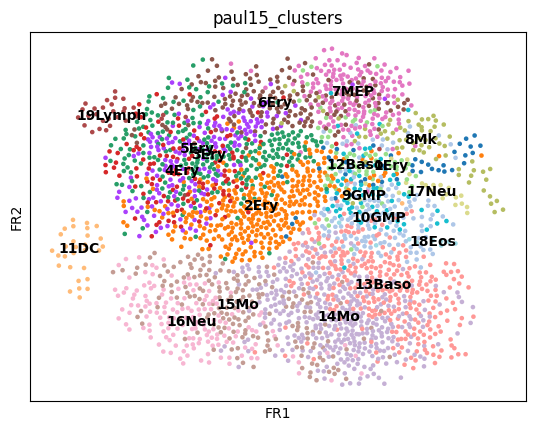

In [10]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

# Optional: Denoising the graph

In [11]:
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

In [12]:
sc.tl.draw_graph(adata)

Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


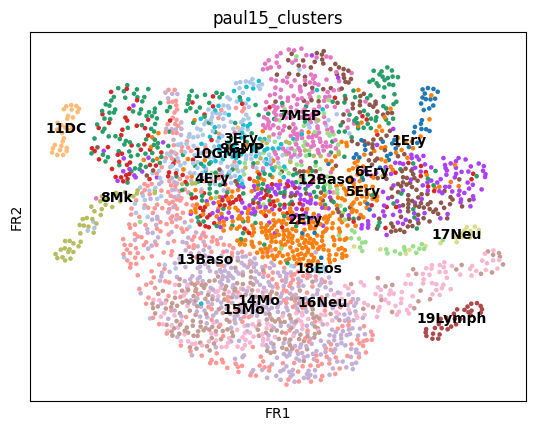

In [12]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

# Clustering and PAGA

In [6]:
sc.tl.louvain(adata, resolution=1.0)

In [7]:
sc.tl.paga(adata, groups="louvain")

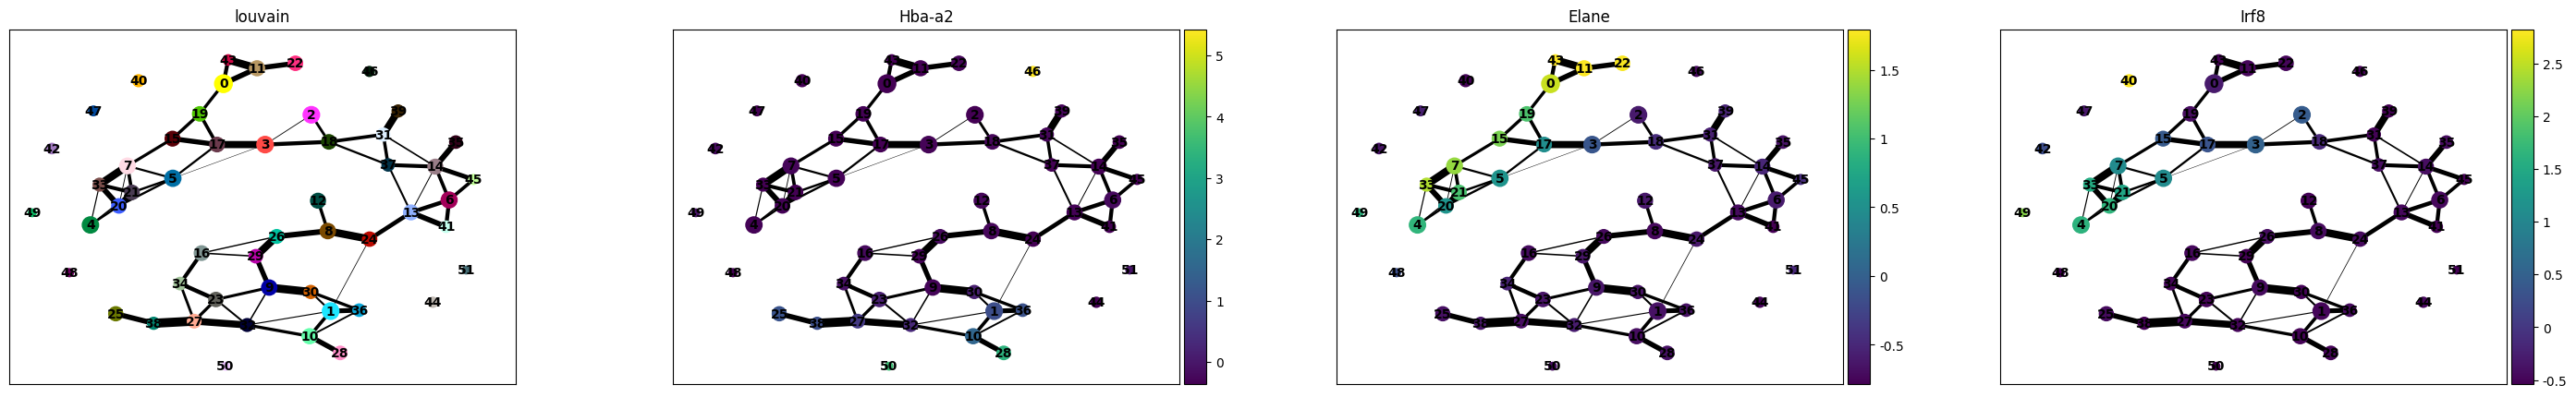

In [8]:
sc.pl.paga(adata, color=["louvain", "Hba-a2", "Elane", "Irf8"])

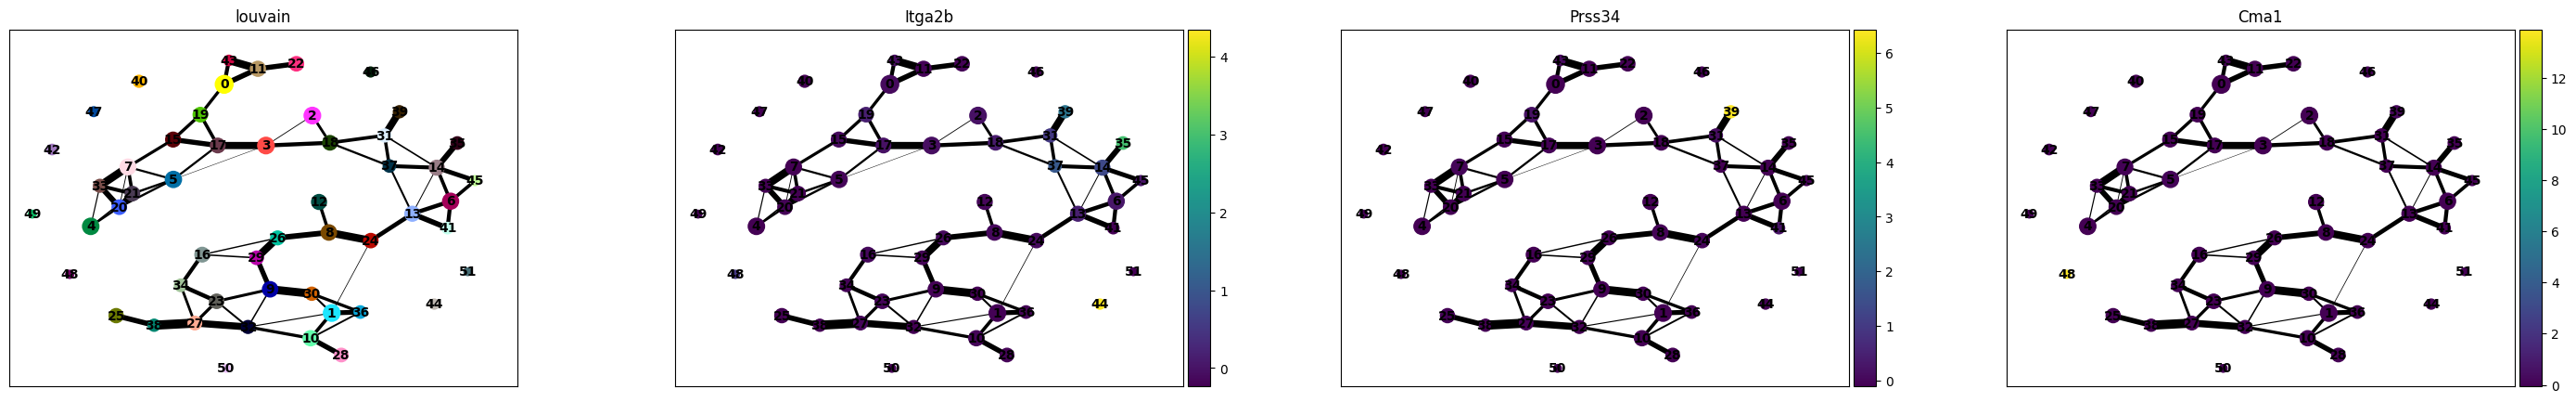

In [9]:
sc.pl.paga(adata, color=["louvain", "Itga2b", "Prss34", "Cma1"])

In [10]:
adata.obs["louvain"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51'],
      dtype='object')

In [11]:
adata.obs["louvain_anno"] = adata.obs["louvain"].cat.rename_categories(
    {
        "10": "10/Ery",
        "16": "16/Stem",
        "19": "19/Neu",
        "20": "20/Mk",
        "22": "22/Baso",
        "24": "24/Mo",
    }
)

In [12]:
sc.tl.paga(adata, groups="louvain_anno")

<Axes: >

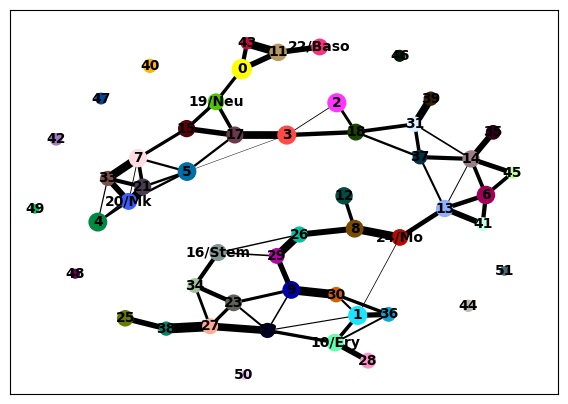

In [13]:
sc.pl.paga(adata, threshold=0.03, show=False)

# Recomputing the embedding using PAGA-initialization

In [14]:
sc.tl.draw_graph(adata, init_pos="paga")

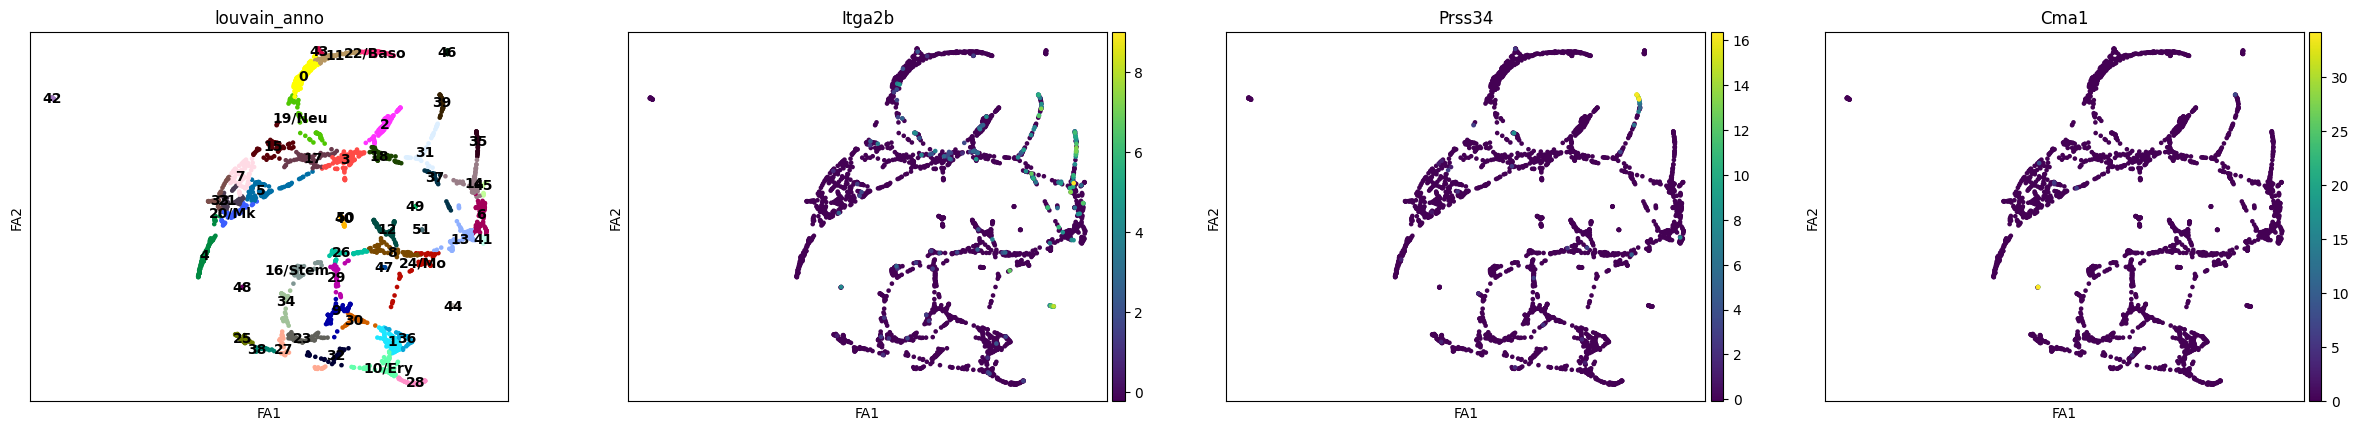

In [15]:
sc.pl.draw_graph(
    adata, color=["louvain_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

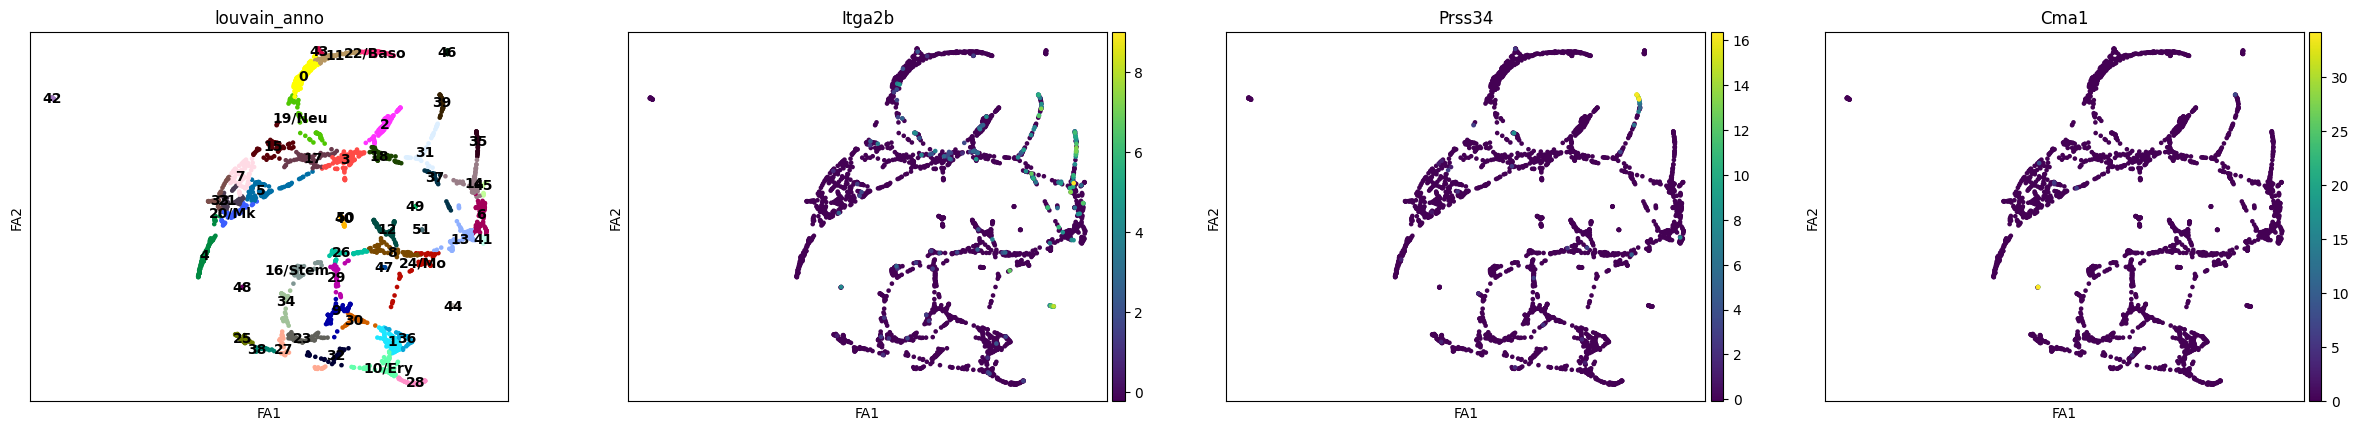

In [16]:
sc.pl.draw_graph(
    adata, color=["louvain_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

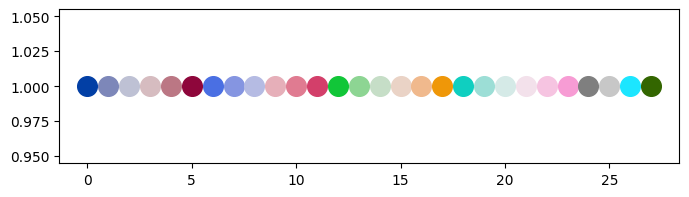

In [17]:
pl.figure(figsize=(8, 2))
for i in range(28):
    pl.scatter(i, 1, c=sc.pl.palettes.zeileis_28[i], s=200)
pl.show()

In [18]:
zeileis_colors = np.array(sc.pl.palettes.zeileis_28)
new_colors = np.array(adata.uns["louvain_anno_colors"])

In [19]:
new_colors[[16]] = zeileis_colors[[12]]  # Stem colors / green
new_colors[[10, 17, 5, 3, 15, 6, 18, 13, 7, 12]] = zeileis_colors[  # Ery colors / red
    [5, 5, 5, 5, 11, 11, 10, 9, 21, 21]
]
new_colors[[20, 8]] = zeileis_colors[[17, 16]]  # Mk early Ery colors / yellow
new_colors[[4, 0]] = zeileis_colors[[2, 8]]  # lymph progenitors / grey
new_colors[[22]] = zeileis_colors[[18]]  # Baso / turquoise
new_colors[[19, 14, 2]] = zeileis_colors[[6, 6, 6]]  # Neu / light blue
new_colors[[24, 9, 1, 11]] = zeileis_colors[[0, 0, 0, 0]]  # Mo / dark blue
new_colors[[21, 23]] = zeileis_colors[[25, 25]]  # outliers / grey

In [20]:
adata.uns["louvain_anno_colors"] = new_colors

saving figure to file figures/paga_compare.pdf


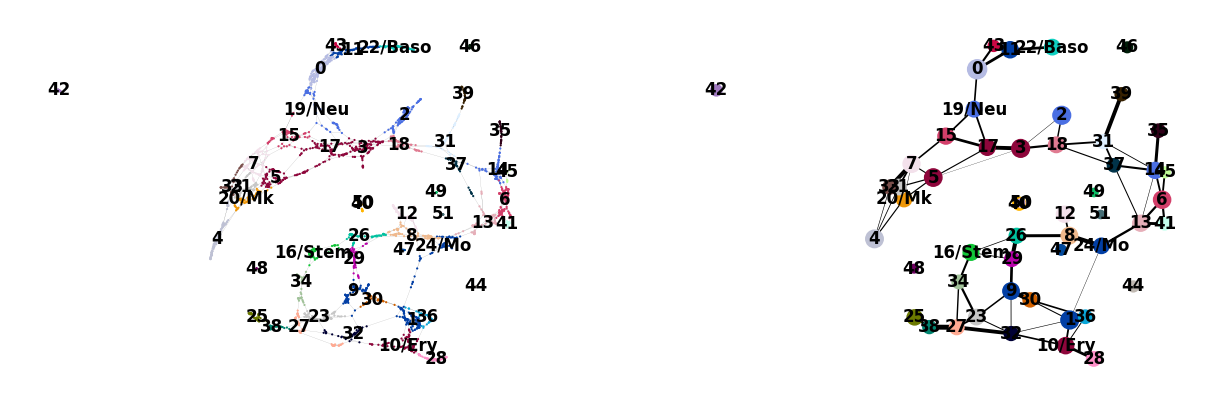

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [21]:
sc.pl.paga_compare(
    adata,
    threshold=0.03,
    title="",
    right_margin=0.2,
    size=10,
    edge_width_scale=0.5,
    legend_fontsize=12,
    fontsize=12,
    frameon=False,
    edges=True,
    save=True,
)

# Reconstructing gene changes along PAGA paths for a given set of genes

In [22]:
adata.uns["iroot"] = np.flatnonzero(adata.obs["louvain_anno"] == "16/Stem")[0]


In [23]:
sc.tl.dpt(adata)


In [24]:
gene_names = [
    *["Gata2", "Gata1", "Klf1", "Epor", "Hba-a2"],  # erythroid
    *["Elane", "Cebpe", "Gfi1"],  # neutrophil
    *["Irf8", "Csf1r", "Ctsg"],  # monocyte
]

In [25]:
adata_raw = sc.datasets.paul15()
sc.pp.log1p(adata_raw)
sc.pp.scale(adata_raw)
adata.raw = adata_raw

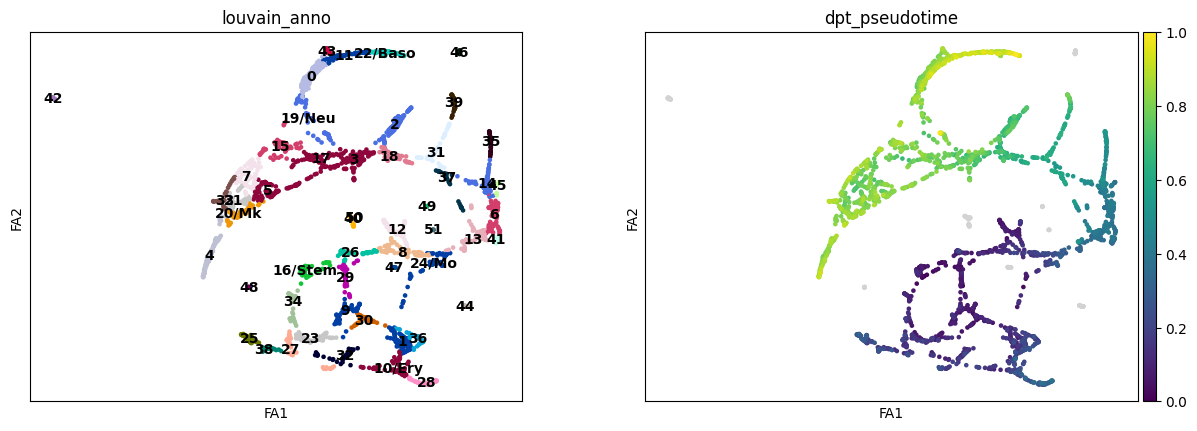

In [26]:
sc.pl.draw_graph(adata, color=["louvain_anno", "dpt_pseudotime"], legend_loc="on data")

In [27]:
paths = [
    ("erythrocytes", [16, 12, 7, 13, 18, 6, 5, 10]),
    ("neutrophils", [16, 0, 4, 2, 14, 19]),
    ("monocytes", [16, 0, 4, 11, 1, 9, 24]),
]

In [28]:
adata.obs["distance"] = adata.obs["dpt_pseudotime"]

In [29]:
adata.obs["clusters"] = adata.obs["louvain_anno"]  # just a cosmetic change

In [30]:
adata.uns["clusters_colors"] = adata.uns["louvain_anno_colors"]

In [31]:
!mkdir write

mkdir: cannot create directory ‘write’: File exists


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_tools/paga.py:1292: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  groups_axis.set_yticklabels(["", xlabel, ""], fontsize=ytick_fontsize)
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_tools/paga.py:1334: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  anno_axis.set_yticklabels(["", anno, ""], fontsize=ytick_fontsize)


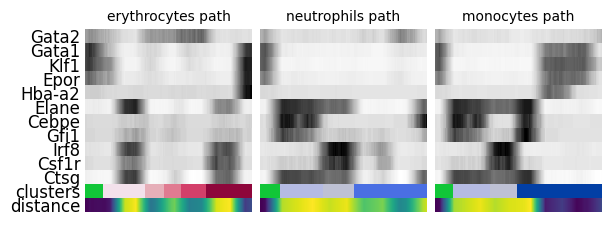

In [32]:
_, axs = pl.subplots(
    ncols=3, figsize=(6, 2.5), gridspec_kw={"wspace": 0.05, "left": 0.12}
)
pl.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)
for ipath, (descr, path) in enumerate(paths):
    data = sc.pl.paga_path(
        adata,
        path,
        gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=12,
        left_margin=0.15,
        n_avg=50,
        annotations=["distance"],
        show_yticks=True if ipath == 0 else False,
        show_colorbar=False,
        color_map="Greys",
        groups_key="clusters",
        color_maps_annotations={"distance": "viridis"},
        title="{} path".format(descr),
        return_data=True,
        show=False,
    )
    data.to_csv("./write/paga_path_{}.csv".format(descr))
pl.savefig("./figures/paga_path_paul15.pdf")
pl.show()

In [33]:
adata

AnnData object with n_obs × n_vars = 2730 × 1000
    obs: 'paul15_clusters', 'n_counts_all', 'louvain', 'louvain_anno', 'dpt_pseudotime', 'distance', 'clusters'
    var: 'n_counts', 'mean', 'std'
    uns: 'iroot', 'log1p', 'pca', 'neighbors', 'draw_graph', 'diffmap_evals', 'louvain', 'paga', 'louvain_sizes', 'louvain_colors', 'louvain_anno_sizes', 'louvain_anno_colors', 'clusters_colors'
    obsm: 'X_pca', 'X_draw_graph_fa', 'X_diffmap', 'X_draw_graph_trajectory'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [34]:
adata.obs['dpt_pseudotime']

W31105    0.404641
W31106    0.822164
W31107    0.153872
W31108    0.798406
W31109    0.210603
            ...   
W39164    0.042137
W39165    0.845035
W39166    0.439261
W39167    0.802026
W39168    0.159336
Name: dpt_pseudotime, Length: 2730, dtype: float32

In [35]:
adata.obs['distance']

W31105    0.404641
W31106    0.822164
W31107    0.153872
W31108    0.798406
W31109    0.210603
            ...   
W39164    0.042137
W39165    0.845035
W39166    0.439261
W39167    0.802026
W39168    0.159336
Name: distance, Length: 2730, dtype: float32

In [36]:
adata.obs['clusters']

W31105     6
W31106    33
W31107    25
W31108     0
W31109    25
          ..
W39164     9
W39165     4
W39166    14
W39167     0
W39168    23
Name: clusters, Length: 2730, dtype: category
Categories (52, object): ['0', '1', '2', '3', ..., '48', '49', '50', '51']

In [37]:
adata.uns['connectivities']

KeyError: 'connectivities'